## Baseline Model

In [1]:
import warnings

from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np

warnings.filterwarnings("ignore")

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier

def eval_classification(y_true, y_pred, name=""):
    acc = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average="macro")
    f1_weighted = f1_score(y_true, y_pred, average="weighted")
    print(f"{name} Accuracy: {acc:.4f} | F1-macro: {f1_macro:.4f} | F1-weighted: {f1_weighted:.4f}")
    return acc, f1_macro, f1_weighted

def save_preds_csv(X_test, y_true, y_pred, filename):
    out = X_test.copy()
    out["y_true"] = y_true
    out["y_pred"] = y_pred
    out.to_csv(filename, index=False, encoding="utf-8-sig")
    print(f"Saved: {filename}")

def derive_groups_from_train(train_df, k_baseline_dict, min_group_size=2):
    """
    Returns: type_to_group dict, groups dict
    Uses only train_df to avoid test leakage.
    Phân loại các 'type' thành near/mid/far dựa trên trung bình độ lệch tuyệt đối (abs_diff)
    """
    df_temp = train_df.copy()
    df_temp["k_eff_expected"] = df_temp["load"].map(k_baseline_dict)
    if df_temp["k_eff_expected"].isnull().any():
        known_loads = np.array(list(k_baseline_dict.keys()))
        for idx, row in df_temp[df_temp["k_eff_expected"].isnull()].iterrows():
            closest_load = known_loads[np.abs(known_loads - row["load"]).argmin()]
            df_temp.loc[idx, "k_eff_expected"] = k_baseline_dict[closest_load]     
    df_temp["abs_diff"] = (df_temp["efficiency"] - df_temp["k_eff_expected"]).abs()
    type_stats = (
        df_temp.groupby("type")["abs_diff"]
        .agg(n="count", mean="mean")
        .sort_values("mean")
        .reset_index()
    )
    types = type_stats["type"].tolist()
    x = type_stats["mean"].to_numpy()
    n = len(x)
    # Prefix sums for O(1) segment SSE
    S1 = np.concatenate([[0.0], np.cumsum(x)])
    S2 = np.concatenate([[0.0], np.cumsum(x * x)])
    def seg_sse(i, j):
        m = j - i + 1
        sum1 = S1[j + 1] - S1[i]
        sum2 = S2[j + 1] - S2[i]
        mu = sum1 / m
        return sum2 - 2 * mu * sum1 + m * mu * mu

    K = 3
    INF = 1e18
    dp = np.full((K + 1, n + 1), INF)
    cut = np.full((K + 1, n + 1), -1, dtype=int)

    dp[0, 0] = 0.0
    for k in range(1, K + 1):
        for t in range(1, n + 1):
            p_min = (k - 1) * min_group_size
            p_max = t - min_group_size
            if p_max < p_min:
                continue
            best_cost, best_p = INF, -1
            for p in range(p_min, p_max + 1):
                cost = dp[k - 1, p] + seg_sse(p, t - 1)
                if cost < best_cost:
                    best_cost, best_p = cost, p
            dp[k, t] = best_cost
            cut[k, t] = best_p

    if np.isinf(dp[K, n]):
        raise RuntimeError("No valid split found. Try min_group_size=1 or check types count.")
    bounds = []
    t = n
    for k in range(K, 0, -1):
        p = cut[k, t]
        bounds.append((p, t))
        t = p
    bounds.reverse()
    group_names = ["near", "mid", "far"] 
    groups = {}
    for name, (a, b) in zip(group_names, bounds):
        groups[name] = types[a:b]

    type_to_group = {t: g for g, ts in groups.items() for t in ts}
    return type_to_group, groups, type_stats


# ----- Load your saved split files -----
train_random = pd.read_csv('../../../random-split/wpt_train_random.csv')
test_random  = pd.read_csv('../../../random-split/wpt_test_random.csv')

# Sanity check expected columns
expected_cols = {"type", "load", "efficiency"}
for name, d in [("train_random", train_random), ("test_random", test_random)]:
    missing = expected_cols - set(d.columns)
    if missing:
        raise ValueError(f"{name} is missing columns: {missing}")

# Make sure numeric columns are numeric
for d in [train_random, test_random]:
    d["load"] = pd.to_numeric(d["load"], errors="coerce")
    d["efficiency"] = pd.to_numeric(d["efficiency"], errors="coerce")
    d["type"] = d["type"].astype(str)
    d.dropna(subset=["type", "load", "efficiency"], inplace=True)

# Features / target
FEATURES = ["load", "efficiency"]
TARGET = "type"

# =========================
def add_advanced_features(df, k_baseline_dict, type_to_group_dict):
    df = df.copy()
    df["k_eff_expected"] = df["load"].map(k_baseline_dict)
    if df["k_eff_expected"].isnull().any():
        known_loads = np.array(list(k_baseline_dict.keys()))
        for idx, row in df[df["k_eff_expected"].isnull()].iterrows():
            closest_load = known_loads[np.abs(known_loads - row["load"]).argmin()]
            df.loc[idx, "k_eff_expected"] = k_baseline_dict[closest_load]  
    # 2. Độ lệch (Difference) và Tỷ lệ (Ratio)
    df["eff_diff"] = df["efficiency"] - df["k_eff_expected"]
    df["eff_ratio"] = df["efficiency"] / df["k_eff_expected"]
    # 3. Ước tính tổn hao công suất (Power Loss Proxy)
    # P_loss = Load * (1 / (Efficiency / 100) - 1)
    df["p_loss"] = df["load"] * (1 / (df["efficiency"] / 100.0) - 1)
    # Tổn hao công suất của Class K
    df["k_p_loss"] = df["load"] * (1 / (df["k_eff_expected"] / 100.0) - 1)
    # Độ lệch suy hao do vật thể lạ gây ra
    df["p_loss_diff"] = df["p_loss"] - df["k_p_loss"]

    df["dist_zone_name"] = df["type"].map(type_to_group_dict).fillna("far")
    # Mã hóa thành số
    zone_mapping = {"near": 1, "mid": 2, "far": 3}
    df["dist_zone"] = df["dist_zone_name"].map(zone_mapping)
    # 4. Phân vùng Dải tải (Load Zone)
    # Giả sử dải tải từ 0.5 đến 3.0, chia làm 3 vùng: Nhẹ (1), Vừa (2), Nặng (3)
    df['load_zone'] = pd.cut(df['load'], bins=3, labels=[1, 2, 3]).astype(float)
    return df

k_baseline_train_r = train_random[train_random["type"] == "K"].groupby("load")["efficiency"].mean().to_dict()
type_to_group, groups_dict, stats = derive_groups_from_train(train_random, k_baseline_train_r)
print("Results of grouping the Types:", groups_dict)

train_random_fe = add_advanced_features(train_random, k_baseline_train_r, type_to_group)
test_random_fe = add_advanced_features(test_random, k_baseline_train_r, type_to_group)

FEATURES_NEW = [
    "load", "efficiency", 
    "eff_diff", "eff_ratio", 
    "p_loss_diff", "load_zone", "dist_zone"
]
# =========================
X_train_r = train_random_fe[FEATURES_NEW]
X_test_r  = test_random_fe[FEATURES_NEW]

# 2. Khởi tạo Label Encoder để dịch chữ sang số cho XGBoost
le = LabelEncoder()

# Fit và transform trên tập Train
y_train_r = le.fit_transform(train_random_fe[TARGET])

# Chỉ transform (không fit) trên tập Test
y_test_r = le.transform(test_random_fe[TARGET])

print("Encoded:", le.classes_)
print("Train dataset is ready:", X_train_r.shape, y_train_r.shape)


Results of grouping the Types: {'near': ['K', 'H', 'J', 'I', 'G'], 'mid': ['F', 'E', 'D', 'B'], 'far': ['C', 'A']}
Encoded: ['A' 'B' 'C' 'D' 'E' 'F' 'G' 'H' 'I' 'J' 'K']
Train dataset is ready: (1310, 7) (1310,)


## Optuna

In [2]:
import optuna

import xgboost as xgb
import json
from sklearn.model_selection import StratifiedKFold, cross_val_score

def objective(trial):
    param = {
        'objective': 'multi:softprob',  # Dùng cho phân loại đa lớp
        'num_class': 11,
        'random_state': 30,
        'verbosity': 0,
        
        # 1. Boosting Type: XGB dùng 'gbtree' (mặc định) hoặc 'dart'
        'booster': trial.suggest_categorical('booster', ['gbtree']),
        
        # 2. Quy mô cây và tốc độ học
        'n_estimators': trial.suggest_int('n_estimators', 100, 1500),
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.2, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        
        # 3. Chống Overfitting (Đặc trưng của XGB)
        'gamma': trial.suggest_float('gamma', 1e-8, 1.0, log=True), # Càng cao càng tránh overfit
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 20),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 1.0),
        
        # 4. Regularization L1, L2
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
    }

    # Lưu ý: XGBoost không có 'class_weight' trực tiếp như LGBM 
    # Nếu dữ liệu cực kỳ lệch, ta thường dùng sample_weight trong lúc fit
    clf = xgb.XGBClassifier(**param)
    
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    # Tính điểm số trung bình (Dùng f1_macro cho 11 lớp)
    scores = cross_val_score(clf, X_train_r, y_train_r, cv=cv, scoring='f1_macro', n_jobs=-1)
    
    return scores.mean()

# Khởi tạo và chạy tối ưu 200 lần
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=200, show_progress_bar=True)

# --- TRÍCH XUẤT VÀ LƯU KẾT QUẢ ---
best_params = study.best_params
best_params.update({
    'objective': 'multi:softprob',
    'num_class': 11,
    'random_state': 30
})

with open("best_xgb_params.json", "w") as f:
    json.dump(best_params, f, indent=4)

print(f"Best Score: {study.best_value}")

[I 2026-03-14 13:24:46,035] A new study created in memory with name: no-name-d2dbf8b2-1c94-4f96-a3ab-fced12241b80


  0%|          | 0/200 [00:00<?, ?it/s]

[I 2026-03-14 13:24:49,884] Trial 0 finished with value: 0.717323257796944 and parameters: {'booster': 'gbtree', 'n_estimators': 1198, 'learning_rate': 0.0792523234626851, 'max_depth': 10, 'gamma': 5.480799898385007e-07, 'min_child_weight': 9, 'subsample': 0.6147332670484886, 'colsample_bytree': 0.9685901483083529, 'reg_alpha': 2.8594470807388237e-08, 'reg_lambda': 1.1201757716329823e-05}. Best is trial 0 with value: 0.717323257796944.
[I 2026-03-14 13:24:52,391] Trial 1 finished with value: 0.732998479973302 and parameters: {'booster': 'gbtree', 'n_estimators': 272, 'learning_rate': 0.003815127526460889, 'max_depth': 8, 'gamma': 0.0005380523040450459, 'min_child_weight': 3, 'subsample': 0.6810363632981713, 'colsample_bytree': 0.7452407454214875, 'reg_alpha': 1.9245179764479262e-08, 'reg_lambda': 0.21536368293347902}. Best is trial 1 with value: 0.732998479973302.
[I 2026-03-14 13:24:55,934] Trial 2 finished with value: 0.7558496344678299 and parameters: {'booster': 'gbtree', 'n_estima

=== Baseline Classification on Random Split ===
RandomSplit Accuracy: 0.7808 | F1-macro: 0.7846 | F1-weighted: 0.7682

Classification report (RandomSplit):
              precision    recall  f1-score   support

           A     1.0000    1.0000    1.0000         4
           B     1.0000    0.9333    0.9655        15
           C     1.0000    1.0000    1.0000         2
           D     0.6667    0.8889    0.7619         9
           E     0.9091    0.7692    0.8333        13
           G     0.8182    1.0000    0.9000         9
           H     0.6757    0.7576    0.7143        33
           I     0.3333    0.3333    0.3333         3
           J     0.6667    0.3478    0.4571        23
           K     0.8250    0.9429    0.8800        35

    accuracy                         0.7808       146
   macro avg     0.7895    0.7973    0.7846       146
weighted avg     0.7787    0.7808    0.7682       146

Saved: optuna_baseline_cm_random_base.csv
Saved: optuna_baseline_preds_random_cls_bas

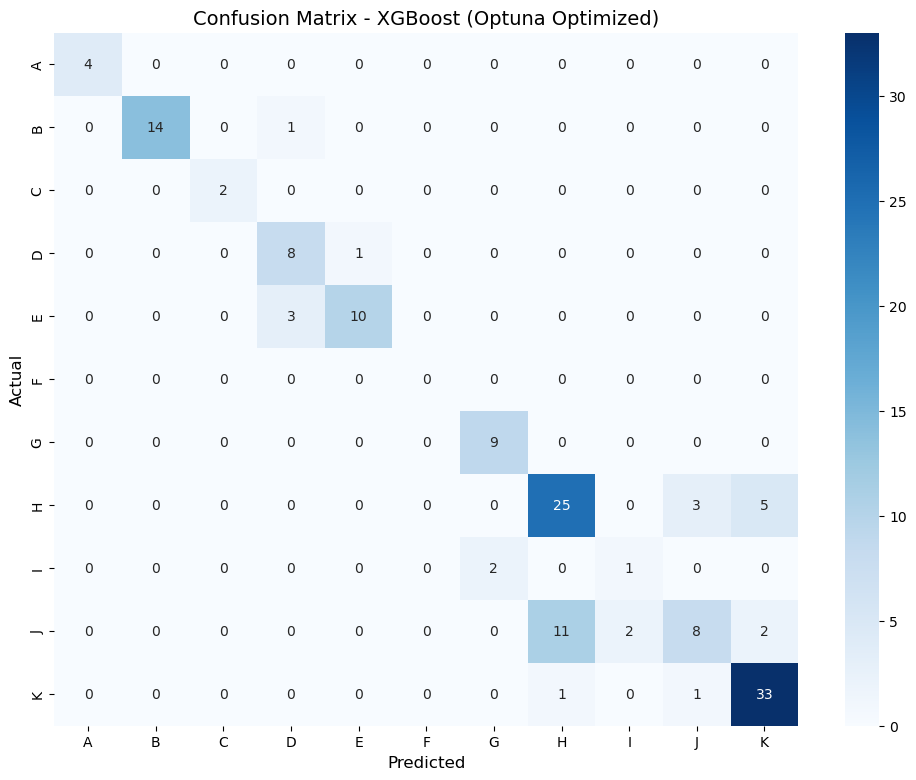

In [3]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import xgboost as xgb
import json
import pandas as pd

file_name = "best_xgb_params.json" 

with open(file_name, "r") as f:
    params = json.load(f)
params.update({
    'objective': 'multi:softprob',
    'num_class': 11,
    'n_jobs': -1 # Bật full CPU để train model cuối cùng cho lẹ
})

# Train model với tham số tốt nhất
best_clf = xgb.XGBClassifier(**params)
best_clf.fit(X_train_r, y_train_r) # Đảm bảo y_train_r ở đây là SỐ nhé

# Dự đoán ra dạng SỐ
pred_r = best_clf.predict(X_test_r).ravel()

# ==========================================================
# PHÉP MÀU NẰM Ở ĐÂY: DỊCH NGƯỢC TỪ SỐ VỀ CHỮ (A, B, C...)
# ==========================================================
# (Giả định 'le' là biến LabelEncoder bạn đã khởi tạo lúc fit dữ liệu)
y_test_text = le.inverse_transform(y_test_r)
pred_text = le.inverse_transform(pred_r)
class_names = le.classes_ # Sẽ trả về mảng ['A', 'B', 'C', ...]

print("=== Baseline Classification on Random Split ===")
# Hàm của bạn tính toán dựa trên số vẫn OK
eval_classification(y_test_r, pred_r, name="RandomSplit")

print("\nClassification report (RandomSplit):")
# In Report bằng CHỮ cho dễ đọc
print(classification_report(y_test_text, pred_text, digits=4))

# --- ĐÃ SỬA LỖI .unique() ---
# Sử dụng mảng class_names thay vì y_train_r.unique()
cm_r = confusion_matrix(y_test_text, pred_text, labels=class_names)
cm_r_df = pd.DataFrame(cm_r, index=class_names, columns=class_names)
cm_r_df.to_csv("optuna_baseline_cm_random_base.csv", encoding="utf-8-sig")
print("Saved: optuna_baseline_cm_random_base.csv")

# Bỏ .values đi vì X_test_r và y_test_text có thể đã là Numpy Array
save_preds_csv(X_test_r, y_test_text, pred_text, "optuna_baseline_preds_random_cls_base.csv")

# Vẽ Confusion Matrix
plt.figure(figsize=(12, 9)) # Phóng to ra một chút cho 11 lớp dễ nhìn
# Đưa cm_r vào và gán nhãn trục x, y bằng class_names
sns.heatmap(cm_r, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - XGBoost (Optuna Optimized)', fontsize=14)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.show()